# Artin Tavasoli - 810102543

### Loading data

In [23]:
import numpy as np

def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

X_train = load_mnist_images('train-images.idx3-ubyte')
y_train = load_mnist_labels('train-labels.idx1-ubyte')
X_test = load_mnist_images('t10k-images.idx3-ubyte')
y_test = load_mnist_labels('t10k-labels.idx1-ubyte')

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


### Calculating and plotting distribution of each class of train/test dataset

In [24]:
num_train_images = X_train.shape[0]
num_test_images = X_test.shape[0]
labels = np.arange(10)

def calc_distribution_labels(df):
    
    count = np.zeros(10).astype(int)

    for i in range(df.shape[0]):
        for j in labels:
            if j == df[i]:
                count[j] += 1
                break

    return count


In [25]:
import matplotlib.pyplot as plt

def plot_distribution_labels(count, name):
    plt.figure(figsize=(8, 5))
    plt.bar(labels, count, color='skyblue', edgecolor='black')

    plt.xlabel('Digit Class')
    plt.ylabel('Number of Images')
    plt.title('Distribution of ' + name + ' MNIST Digits')
    plt.xticks(labels)
    plt.show()

train data distribution of labels is: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


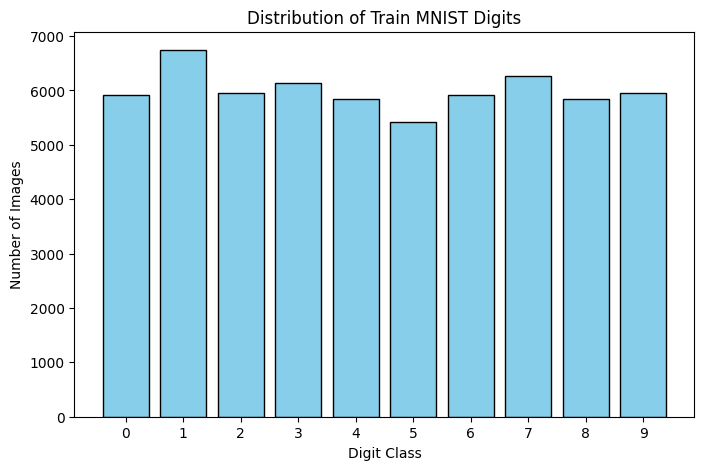

test data distribution of labels is: [ 980 1135 1032 1010  982  892  958 1028  974 1009]


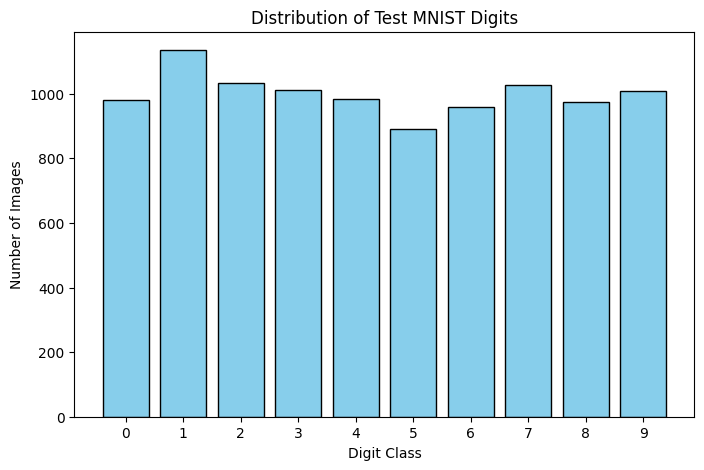

In [26]:
count_train = calc_distribution_labels(y_train)
print('train data distribution of labels is:', count_train)
plot_distribution_labels(count_train, 'Train')
count_test= calc_distribution_labels(y_test)
print('test data distribution of labels is:', count_test)
plot_distribution_labels(count_test, 'Test')

### Preprocess data

We normalize image pixel values to [0, 1] and flatten them to 784 (28*28) dimensions

In [27]:
def preprocess_data(images):

    images = images.astype(np.float32) / 255.0
    
    images = images.reshape(-1, 784)
    
    return images

In [28]:
X_train = preprocess_data(X_train)
print("after preprocessing train data shape is: ", X_train.shape)
X_test = preprocess_data(X_test)
print("after preprocessing test data shape is: ", X_test.shape)

after preprocessing train data shape is:  (60000, 784)
after preprocessing test data shape is:  (10000, 784)


### Hyperparameters

In [29]:
batch_size = 64
learning_rate = 0.001
epochs = 30

### Preparing data for pytorch models

we convert numpy arrays to pytorch tensors.

for an autoencoder, the input is the same as the target (the loss is calculated using the MSE loss between input and models prediction (reconstructed image))

In [30]:
import torch
from torch.utils.data import TensorDataset, DataLoader

tensor_X_train = torch.tensor(X_train, dtype=torch.float32)

train_dataset = TensorDataset(tensor_X_train, tensor_X_train)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [31]:
import torch.nn as nn

class Autoencoder_V1(nn.Module):
    def __init__(self):
        super(Autoencoder_V1, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128, 8),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.ReLU()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat
    

model_V1 = Autoencoder_V1()



In [32]:
import torch.nn as nn

class Autoencoder_V2(nn.Module):
    def __init__(self):
        super(Autoencoder_V2, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128, 4),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.ReLU()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat
    

model_V2 = Autoencoder_V2()



In [33]:
def train_autoencoder(model, optimizer):
    criterion = nn.MSELoss() 
    history = {'loss': [], 'accuracy': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        
        for batch_images, target_images in train_loader:
           
            reconstructed_images = model(batch_images)
            
            loss = criterion(reconstructed_images, target_images)
            
            optimizer.zero_grad() 
            loss.backward()       
            optimizer.step()
            
            total_loss += loss.item() 
            
        avg_loss = total_loss / len(train_loader)
        
        history['loss'].append(avg_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")
        
    return history


In [34]:
total_num_params_V1 = 0

for param in model_V1.parameters():
    total_num_params_V1 += param.numel()

print("Model V1 (bottleneck dim=8) total number of parameters: ", total_num_params_V1)


total_num_params_V2 = 0

for param in model_V2.parameters():
    total_num_params_V2 +=  param.numel()

print("Model V2 (bottleneck dim=4) total number of parameters: ", total_num_params_V2)

Model V1 (bottleneck dim=8) total number of parameters:  203800
Model V2 (bottleneck dim=4) total number of parameters:  202772


In [35]:
import torch.optim as optim
import matplotlib.pyplot as plt

print("Model V1 (bottleneck dim=8) loss in each epoch:")
optimizer_V1 = optim.Adam(model_V1.parameters(), lr=learning_rate)
history_V1 = train_autoencoder(model_V1, optimizer_V1)

print("Model V2 (bottleneck dim=4) loss in each epoch:")
optimizer_V2 = optim.Adam(model_V2.parameters(), lr=learning_rate)
history_V2 = train_autoencoder(model_V2, optimizer_V2)

Model V1 (bottleneck dim=8) loss in each epoch:
Epoch [1/30], Loss: 0.0460
Epoch [2/30], Loss: 0.0380
Epoch [3/30], Loss: 0.0365
Epoch [4/30], Loss: 0.0356
Epoch [5/30], Loss: 0.0350
Epoch [6/30], Loss: 0.0347
Epoch [7/30], Loss: 0.0344
Epoch [8/30], Loss: 0.0342
Epoch [9/30], Loss: 0.0339
Epoch [10/30], Loss: 0.0337
Epoch [11/30], Loss: 0.0335
Epoch [12/30], Loss: 0.0334
Epoch [13/30], Loss: 0.0334
Epoch [14/30], Loss: 0.0333
Epoch [15/30], Loss: 0.0331
Epoch [16/30], Loss: 0.0329
Epoch [17/30], Loss: 0.0328
Epoch [18/30], Loss: 0.0328
Epoch [19/30], Loss: 0.0327
Epoch [20/30], Loss: 0.0327
Epoch [21/30], Loss: 0.0326
Epoch [22/30], Loss: 0.0326
Epoch [23/30], Loss: 0.0325
Epoch [24/30], Loss: 0.0325
Epoch [25/30], Loss: 0.0325
Epoch [26/30], Loss: 0.0324
Epoch [27/30], Loss: 0.0322
Epoch [28/30], Loss: 0.0321
Epoch [29/30], Loss: 0.0321
Epoch [30/30], Loss: 0.0320
Model V2 (bottleneck dim=4) loss in each epoch:
Epoch [1/30], Loss: 0.0642
Epoch [2/30], Loss: 0.0582
Epoch [3/30], Loss:

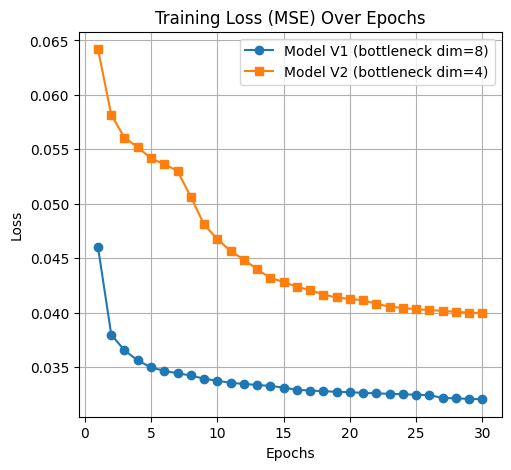

In [36]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_V1['loss'], label='Model V1 (bottleneck dim=8)', marker='o')
plt.plot(epochs_range, history_V2['loss'], label='Model V2 (bottleneck dim=4)', marker='s')
plt.title('Training Loss (MSE) Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


### Adding classifier heads to encoders above (encoders stay frozen)

preparing the data

In [37]:
tensor_y_train = torch.tensor(y_train, dtype=torch.long)
tensor_X_test = torch.tensor(X_test, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test, dtype=torch.long)

train_cls_dataset = TensorDataset(tensor_X_train, tensor_y_train)
test_cls_dataset = TensorDataset(tensor_X_test, tensor_y_test)

train_cls_loader = DataLoader(train_cls_dataset, batch_size=batch_size, shuffle=True)
test_cls_loader = DataLoader(test_cls_dataset, batch_size=batch_size, shuffle=False)

Classifiers

In [38]:
class Classifier_V1(nn.Module):
    def __init__(self, encoder):
        super(Classifier_V1, self).__init__()
        self.encoder = encoder
        
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        self.classifier = nn.Sequential(
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 10)
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.classifier(z)
        return logits
    
cls_model_V1 = Classifier_V1(model_V1.encoder)


In [39]:
class Classifier_V2(nn.Module):
    def __init__(self, encoder):
        super(Classifier_V2, self).__init__()
        self.encoder = encoder
        
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        self.classifier = nn.Sequential(
            nn.Linear(4, 10)
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.classifier(z)
        return logits
    
cls_model_V2 = Classifier_V2(model_V2.encoder)


Hyperparameters

In [40]:
learning_rate = 0.001
epochs = 30

Training and evaluating through epochs

In [41]:
def train_and_evaluate(model, optimizer):
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}


    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        num_train_correct_predictions = 0
        num_train_images = 0
        
        for inputs, targets in train_cls_loader:
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item() * inputs.size(0)
            
            _, predictions = torch.max(logits.data, 1)

            num_train_images += targets.size(0)
            
            temp = 0
            for i in range(len(predictions)):
                if predictions[i] == targets[i]:
                    temp += 1

            num_train_correct_predictions += temp
            
        avg_train_loss = total_train_loss / num_train_images
        train_acc = num_train_correct_predictions / num_train_images
        
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)




        
        model.eval()
        total_test_loss = 0.0
        num_test_correct_predictions = 0
        num_test_images = 0
        
        with torch.no_grad():
            for inputs, targets in test_cls_loader:
                logits = model(inputs)
                loss = criterion(logits, targets)
                
                total_test_loss += loss.item() * inputs.size(0)

                _, predictions = torch.max(logits.data, 1)

                num_test_images += targets.size(0)
                
                temp = 0
                for i in range(len(predictions)):
                    if predictions[i] == targets[i]:
                        temp += 1

                num_test_correct_predictions += temp
                
        avg_test_loss = total_test_loss / num_test_images
        test_acc = num_test_correct_predictions / num_test_images

        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_acc)
        
        
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_acc:.4f}")
              
    return history

Number of parameters of each classifer

In [42]:
params_to_optimize_V1 = []
total_num_params_V1 = 0
frozen_num_params_V1 = 0
unfrozen_num_params_V1 = 0 

for param in cls_model_V1.parameters():
    total_num_params_V1 += param.numel()
    if param.requires_grad:
        unfrozen_num_params_V1 += param.numel()
        params_to_optimize_V1.append(param)
    else:
        frozen_num_params_V1 += param.numel()

print("Classifier V1 (encoder dim=8) parameter summary:")
print("total: ", total_num_params_V1)
print("frozen: ", frozen_num_params_V1)
print("unfrozen: ", unfrozen_num_params_V1)

params_to_optimize_V2 = []
total_num_params_V2 = 0
frozen_num_params_V2 = 0
unfrozen_num_params_V2 = 0 

for param in cls_model_V2.parameters():
    total_num_params_V2 += param.numel()
    if param.requires_grad:
        unfrozen_num_params_V2 += param.numel()
        params_to_optimize_V2.append(param)
    else:
        frozen_num_params_V2 += param.numel()

print("Classifier V2 (encoder dim=4) parameter summary:")
print("total: ", total_num_params_V2)
print("frozen: ", frozen_num_params_V2)
print("unfrozen: ", unfrozen_num_params_V2)




Classifier V1 (encoder dim=8) parameter summary:
total:  101598
frozen:  101512
unfrozen:  86
Classifier V2 (encoder dim=4) parameter summary:
total:  101046
frozen:  100996
unfrozen:  50


In [43]:
print("Classifier V1 (encoder dim=8) loss in each epoch:")

optimizer_cls_V1 = optim.Adam(params_to_optimize_V1, lr=learning_rate)

history_cls_V1 = train_and_evaluate(cls_model_V1, optimizer_cls_V1)


print("Classifier V2 (encoder dim=4) loss in each epoch:")


optimizer_cls_V2 = optim.Adam(params_to_optimize_V2, lr=learning_rate)

history_cls_V2 = train_and_evaluate(cls_model_V2, optimizer_cls_V2)

Classifier V1 (encoder dim=8) loss in each epoch:
Epoch [1/30] | Train Loss: 1.6241, Train Acc: 0.4237 | Test Loss: 1.1054, Test Acc: 0.6516
Epoch [2/30] | Train Loss: 0.8542, Train Acc: 0.7345 | Test Loss: 0.7221, Test Acc: 0.7744
Epoch [3/30] | Train Loss: 0.6886, Train Acc: 0.7798 | Test Loss: 0.6727, Test Acc: 0.7880
Epoch [4/30] | Train Loss: 0.6577, Train Acc: 0.7867 | Test Loss: 0.6539, Test Acc: 0.7907
Epoch [5/30] | Train Loss: 0.6454, Train Acc: 0.7918 | Test Loss: 0.6447, Test Acc: 0.7947
Epoch [6/30] | Train Loss: 0.6370, Train Acc: 0.7940 | Test Loss: 0.6413, Test Acc: 0.7929
Epoch [7/30] | Train Loss: 0.6306, Train Acc: 0.7970 | Test Loss: 0.6347, Test Acc: 0.7976
Epoch [8/30] | Train Loss: 0.6240, Train Acc: 0.7996 | Test Loss: 0.6261, Test Acc: 0.8051
Epoch [9/30] | Train Loss: 0.6170, Train Acc: 0.8031 | Test Loss: 0.6204, Test Acc: 0.8040
Epoch [10/30] | Train Loss: 0.6101, Train Acc: 0.8059 | Test Loss: 0.6149, Test Acc: 0.8130
Epoch [11/30] | Train Loss: 0.6042, Tra

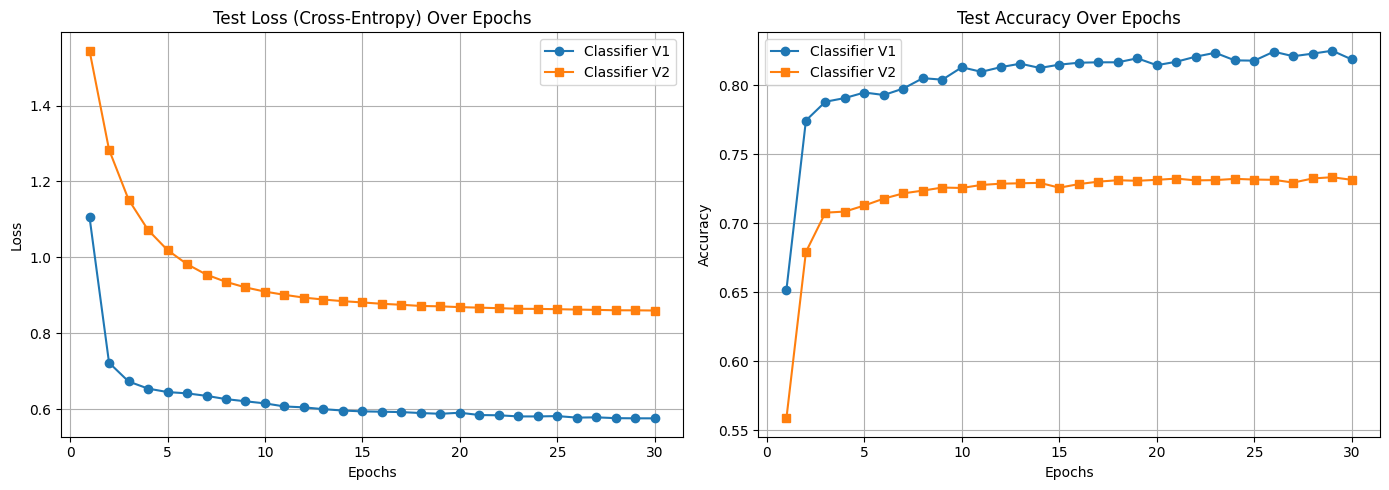

In [44]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_cls_V1['test_loss'], label='Classifier V1', marker='o')
plt.plot(epochs_range, history_cls_V2['test_loss'], label='Classifier V2', marker='s')
plt.title('Test Loss (Cross-Entropy) Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_cls_V1['test_acc'], label='Classifier V1', marker='o')
plt.plot(epochs_range, history_cls_V2['test_acc'], label='Classifier V2', marker='s')
plt.title('Test Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()